## 0.1 Init ambiente Google Colab

Conectar la virtual machine donde esta corriendo Google Colab con el Google Drive, para poder tener persistencia de archivos

In [1]:
# primero establecer el Runtime de Python 3
from google.colab import drive
drive.mount('/content/.drive')


Drive already mounted at /content/.drive; to attempt to forcibly remount, call drive.mount("/content/.drive", force_remount=True).


In [2]:
%%shell

mkdir -p "/content/.drive/My Drive/labo3"
mkdir -p "/content/buckets"
ln -sfn "/content/.drive/My Drive/labo3"   /content/buckets/b1

mkdir -p ~/.kaggle
cp /content/buckets/b1/kaggle/kaggle.json  ~/.kaggle
chmod 600 ~/.kaggle/kaggle.json


mkdir -p /content/buckets/b1/exp
mkdir -p /content/buckets/b1/datasets
mkdir -p /content/datasets


# defino funcion descargar()
descargar() {
  carpeta_destino="/content/buckets/b1/datasets/"
  url_origen="https://storage.googleapis.com/open-courses/austral2026-5da5/labo3/"
  archivo="$1"

  if ! test -f "$carpeta_destino""$archivo"; then
    wget  "$url_origen""$archivo"  -O "$carpeta_destino""$archivo"
  fi

  if ! test -f  "/content/datasets/""$archivo"; then
    cp  "$carpeta_destino""$archivo"  "/content/datasets/""$archivo"
  fi;
}


# hago la descarga efectiva, llamando a descargar()
descargar  "sell-in.txt.gz"
descargar  "tb_productos.txt"
descargar  "tb_stocks.txt"
descargar  "product_id_apredecir201912.txt"


Ademas de los datasets originales, este notebook necesita `sell-in-zeroes.txt.gz`, generado por z601_workflow_ceros.
<br>El output queda guardado en `/content/buckets/b1/datasets/sell-in-zeroes.txt.gz`.

In [3]:
import os as os

# verifico que exista el dataset con ceros (generado por z601)
ruta_zeroes = "/content/buckets/b1/datasets/sell-in-zeroes.txt.gz"

if not os.path.isfile(ruta_zeroes):
    raise FileNotFoundError(
        "No se encontro sell-in-zeroes.txt.gz. "
        "Correr primero z601_workflow_ceros.ipynb"
    )
else:
    print("OK, encontrado:", ruta_zeroes)


OK, encontrado: /content/buckets/b1/datasets/sell-in-zeroes.txt.gz


## 0.2 Estructura de carpetas del experimento

In [4]:
# defino los parametros del experimento
PARAM = {
    'experimento': 'LGBM-01',
    'kaggle_competition': 'labo-iii-2026-ba',
    'semilla_primigenia': 103132      # mi semilla
}


In [5]:
# creo la carpeta del experimento y hago el chdir
ruta = "/content/buckets/b1/exp/" + PARAM['experimento']
print(ruta)
os.makedirs(ruta, exist_ok=True)
os.chdir(ruta)


/content/buckets/b1/exp/LGBM-01


In [6]:
# funcion para hacer submits a Kaggle (identica a la usada en z316 / z403)
def kaggle_submit(competencia, archivo, mensaje):
    comando = f'kaggle competitions submit -c {competencia} -f {archivo} -m "{mensaje}"'
    os.system(comando)


## 0.3 Instalación de paquetes

In [7]:
# paquetes que no vienen instalados por default
!pip install -q uv
!uv pip install -q kaggle
!uv pip install -q lightgbm polars dtaidistance scipy scikit-learn


In [8]:
import numpy as np
import polars as pl
import polars.selectors as cs
import lightgbm as lgb

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

np.random.seed(PARAM['semilla_primigenia'])


# 1 Carga de datos

Cargo el dataset ampliado con ceros (`sell-in-zeroes`, granularidad `<cliente,producto,periodo>`), el maestro de productos y la tabla de stocks.

In [9]:
# sell-in con ceros agregados (salida de z601_workflow_ceros)
# OJO: el COPY ... (FORMAT csv, COMPRESSION 'gzip') de DuckDB escribe HEADER por defecto
# y separador coma (no tab). Por eso leemos con has_header=True.
tb_sellin = pl.read_csv(
    '/content/buckets/b1/datasets/sell-in-zeroes.txt.gz',
    has_header=True,
    separator=","
)

tb_sellin = tb_sellin.sort(["customer_id", "product_id", "periodo"])

# --- AJUSTE RAM: downcast de tipos apenas se carga, antes de cualquier otra cosa ---
# customer_id/product_id/periodo vienen como Int64 y tn como Float64 por default de polars;
# eso pesa el doble de lo necesario en TODO lo que sigue (DTW, clustering, joins, features).
# Los rangos reales (periodo tipo YYYYMM, ids de la competencia) entran comodos en Int32/Float32.
tb_sellin = tb_sellin.with_columns([
    pl.col("customer_id").cast(pl.Int32),
    pl.col("product_id").cast(pl.Int32),
    pl.col("periodo").cast(pl.Int32),
    pl.col("tn").cast(pl.Float32),
])

print(tb_sellin.shape)
print(tb_sellin.dtypes)
print(f"tamano estimado en RAM: {tb_sellin.estimated_size('mb'):.1f} MB")
tb_sellin.head()


(17173448, 7)
[Int32, Int32, Int32, Int64, Int64, Float64, Float32]
tamano estimado en RAM: 655.1 MB


customer_id,product_id,periodo,plan_precios_cuidados,cust_request_qty,cust_request_tn,tn
i32,i32,i32,i64,i64,f64,f32
10001,20001,201701,0,11,99.43861,99.438606
10001,20001,201702,0,23,198.84365,198.843643
10001,20001,201703,0,33,92.46537,92.46537
10001,20001,201704,0,8,13.29728,13.29728
10001,20001,201705,0,15,101.20711,101.00563


In [10]:
# maestro de productos
tb_productos = pl.read_csv(
    '/content/datasets/tb_productos.txt', separator="\t"
)

print(tb_productos.shape)
tb_productos.head()


(1251, 7)


cat1,cat2,cat3,brand,sku_size,product_id,descripcion
str,str,str,str,i64,i64,str
"""FOODS""","""ADEREZOS""","""Aji Picante""","""NATURA""",240,20609,"""Salsa Aji Picante"""
"""FOODS""","""ADEREZOS""","""Barbacoa""","""NATURA""",250,20266,"""Salsa Barbacoa"""
"""FOODS""","""ADEREZOS""","""Barbacoa""","""NATURA""",400,20325,"""Salsa Barbacoa"""
"""FOODS""","""ADEREZOS""","""Barbacoa""","""NATURA""",500,20503,"""Salsa Barbacoa"""
"""FOODS""","""ADEREZOS""","""Chimichurri""","""NATURA""",350,20797,"""Chimichurri"""


In [11]:
# stock final por producto y periodo
tb_stocks = pl.read_csv(
    '/content/datasets/tb_stocks.txt', separator="\t"
)

print(tb_stocks.shape)
tb_stocks.head()


(13691, 3)


periodo,product_id,stock_final
i64,i64,f64
201810,20524,1.61267
201810,20311,2.93657
201810,20654,6.83269
201810,21005,1.01338
201810,20974,0.34595


In [12]:
# tabla con los 780 product_id que hay que predecir para 202002
tb_apredecir = pl.read_csv(
    '/content/datasets/product_id_apredecir201912.txt', separator="\t"
)

print(tb_apredecir.shape)
tb_apredecir.head()


(780, 1)


product_id
i64
20001
20002
20003
20004
20005


### 1.1 Verificaciones básicas
Chequeos rápidos de sanidad antes de seguir: cantidad de periodos, rango de fechas, nulos, y que los 780 productos a predecir existan en `tb_sellin`.

In [13]:
# rango de periodos disponibles
print("periodos:", tb_sellin["periodo"].min(), "-", tb_sellin["periodo"].max())
print("cantidad de periodos distintos:", tb_sellin["periodo"].n_unique())
print("cantidad de clientes distintos:", tb_sellin["customer_id"].n_unique())
print("cantidad de productos distintos:", tb_sellin["product_id"].n_unique())


periodos: 201701 - 201912
cantidad de periodos distintos: 36
cantidad de clientes distintos: 597
cantidad de productos distintos: 1233


In [14]:
# nulos por columna
tb_sellin.null_count()


customer_id,product_id,periodo,plan_precios_cuidados,cust_request_qty,cust_request_tn,tn
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0


In [15]:
# los 780 productos a predecir, ¿todos tienen historia en tb_sellin?
productos_en_sellin = tb_sellin["product_id"].unique()
faltantes = tb_apredecir.filter(~pl.col("product_id").is_in(productos_en_sellin))

print("productos a predecir sin historia en sell-in:", faltantes.height)
faltantes


productos a predecir sin historia en sell-in: 0


product_id
i64


# 2 Agregaciones globales (livianas)

Estas agregaciones se calculan una sola vez, sobre el dataset completo, antes de particionar por cluster.
Son livianas porque son simples `group_by` (no explotan en columnas ni multiplican filas), así que no comprometen la RAM.

Después, dentro de cada cluster, se van a hacer `join` contra estas tablas para incorporar contexto de mercado/producto/cliente que el cluster no puede ver por sí solo.

### 2.1 Producto base (agrupación cross-tamaño)

In [16]:
# identifico el "producto base" (mismo producto, distintos sku_size)
# agrupando por todo menos el tamaño
tb_producto_base = tb_productos.with_columns(
    pl.concat_str(
        [pl.col("cat1"), pl.col("cat2"), pl.col("cat3"), pl.col("brand"), pl.col("descripcion")],
        separator="|"
    ).alias("producto_base_id")
).select(["product_id", "producto_base_id"])

tb_producto_base.head()


product_id,producto_base_id
i64,str
20609,"""FOODS|ADEREZOS|Aji Picante|NAT…"
20266,"""FOODS|ADEREZOS|Barbacoa|NATURA…"
20325,"""FOODS|ADEREZOS|Barbacoa|NATURA…"
20503,"""FOODS|ADEREZOS|Barbacoa|NATURA…"
20797,"""FOODS|ADEREZOS|Chimichurri|NAT…"


### 2.2 Σ tn por producto y periodo (demanda total de mercado)

In [17]:
# suma de tn de TODOS los clientes, para cada product_id y periodo
tb_agg_producto_periodo = (
    tb_sellin
    .group_by(["product_id", "periodo"])
    .agg(pl.col("tn").sum().alias("tn_total_producto"))
    .sort(["product_id", "periodo"])
)

tb_agg_producto_periodo.head()


product_id,periodo,tn_total_producto
i32,i32,f32
20001,201701,934.772217
20001,201702,798.016174
20001,201703,1303.357666
20001,201704,1069.961304
20001,201705,1502.201294


### 2.3 Σ tn por cliente y periodo (consumo total del cliente)

In [18]:
# suma de tn de TODOS los productos, para cada customer_id y periodo
tb_agg_cliente_periodo = (
    tb_sellin
    .group_by(["customer_id", "periodo"])
    .agg(pl.col("tn").sum().alias("tn_total_cliente"))
    .sort(["customer_id", "periodo"])
)

tb_agg_cliente_periodo.head()


customer_id,periodo,tn_total_cliente
i32,i32,f32
10001,201701,2543.899414
10001,201702,3007.082764
10001,201703,3772.797119
10001,201704,3283.442139
10001,201705,3753.20459


### 2.4 Σ tn por producto base y periodo (mismo producto, todos los tamaños)

In [19]:
# uno sell-in con el mapeo product_id -> producto_base_id, y sumo tn de TODOS los clientes
# y TODOS los tamaños de ese producto base, por periodo
tb_agg_base_periodo = (
    tb_sellin
    .join(tb_producto_base, on="product_id", how="left")
    .group_by(["producto_base_id", "periodo"])
    .agg(pl.col("tn").sum().alias("tn_total_producto_base"))
    .sort(["producto_base_id", "periodo"])
)

tb_agg_base_periodo.head()


producto_base_id,periodo,tn_total_producto_base
str,i32,f32
null,201701,70.037521
null,201702,34.440331
null,201703,29.06974
null,201704,18.527571
null,201705,21.378479


### 2.5 Σ tn de mercado total por periodo

In [20]:
# demanda total del mercado (todos los productos, todos los clientes) por periodo
tb_agg_mercado_periodo = (
    tb_sellin
    .group_by("periodo")
    .agg(pl.col("tn").sum().alias("tn_total_mercado"))
    .sort("periodo")
)

tb_agg_mercado_periodo.head()


periodo,tn_total_mercado
i32,f32
201701,34057.617188
201702,34568.84375
201703,46041.554688
201704,39626.386719
201705,45580.914062


### 2.6 Stock de producto por periodo (features de cobertura de stock)

`tb_stocks` se cargaba en la seccion 1 pero no se usaba en ningun feature. El nivel de stock es un predictor fuerte de ventas futuras: si un producto se queda sin stock, la demanda cae aunque el mercado la siga pidiendo.


In [21]:
# normalizo nombres de columna por las dudas (espacios, mayusculas)
tb_stock_producto_periodo = tb_stocks.rename({c: c.strip().lower() for c in tb_stocks.columns})

# me quedo solo con lo que necesito: 1 fila por producto y periodo
tb_stock_producto_periodo = (
    tb_stock_producto_periodo
    .select(["periodo", "product_id", "stock_final"])
    .sort(["product_id", "periodo"])
)

# stock relativo a la demanda del producto ese mes ("meses de cobertura" aproximados)
tb_stock_producto_periodo = (
    tb_stock_producto_periodo
    .join(tb_agg_producto_periodo, on=["product_id", "periodo"], how="left")
    .with_columns(
        (pl.col("stock_final") / (pl.col("tn_total_producto") + 1e-6)).alias("stock_cobertura_meses")
    )
    .select(["periodo", "product_id", "stock_final", "stock_cobertura_meses"])
)

# variacion de stock mes a mes (¿se esta acumulando o vaciando?)
tb_stock_producto_periodo = tb_stock_producto_periodo.with_columns(
    (pl.col("stock_final") - pl.col("stock_final").shift(1).over("product_id")).alias("stock_delta")
)

print(tb_stock_producto_periodo.shape)
tb_stock_producto_periodo.head()


(13691, 5)


periodo,product_id,stock_final,stock_cobertura_meses,stock_delta
i64,i64,f64,f64,f64
201810,20001,33.65111,0.014662,null
201811,20001,47.44089,0.026167,13.78978
201812,20001,680.20271,0.457529,632.76182
201901,20001,544.71331,0.426967,-135.4894
201902,20001,546.07997,0.433709,1.36666


# 3 Clusterización de clientes (DTW + jerárquico)

Objetivo: agrupar clientes con series de venta de forma similar para después entrenar un LightGBM por cluster

Uso la tabla `tb_agg_cliente_periodo` (Σ tn por cliente y periodo, ya calculada en 2.3) como perfil de cada cliente. Cada cliente puede tener distinta cantidad de periodos activos — eso no es problema para DTW, que compara series de largo variable.

### 3.1 Armado de las series por cliente

In [22]:
# lista ordenada de customer_id (defino el orden una vez, y lo uso en todos lados de esta seccion)
clientes = tb_agg_cliente_periodo["customer_id"].unique().sort().to_list()

print("cantidad de clientes a clusterizar:", len(clientes))


cantidad de clientes a clusterizar: 597


In [23]:
# para cada cliente, arreglo su serie de tn_total_cliente ordenada por periodo
# (largo variable entre clientes: cada uno arranca cuando hizo su primera compra)
series_por_cliente = {}

for cid, sub in tb_agg_cliente_periodo.sort(["customer_id", "periodo"]).group_by("customer_id", maintain_order=True):
    series_por_cliente[cid[0]] = sub["tn_total_cliente"].to_numpy()

# ejemplo: largo de la serie de los primeros 5 clientes
for cid in clientes[:5]:
    print(cid, "->", len(series_por_cliente[cid]), "periodos")


10001 -> 36 periodos
10002 -> 36 periodos
10003 -> 36 periodos
10004 -> 36 periodos
10005 -> 36 periodos


### 3.2 Normalización de las series (z-score)
Para clusterizar por forma de la serie y no por magnitud (la magnitud ya está reflejada en el orden de `customer_id`, según tus notas), normalizo cada serie a media 0 y desvío 1 antes de calcular las distancias DTW.

In [24]:
def zscore(serie):
    mu = serie.mean()
    sd = serie.std()
    if sd == 0 or np.isnan(sd):
        return serie - mu  # serie constante -> queda todo en cero
    return (serie - mu) / sd

series_norm = [zscore(series_por_cliente[cid].astype(float)) for cid in clientes]


### 3.3 Matriz de distancias DTW

In [25]:
from dtaidistance import dtw

# matriz de distancias DTW entre todos los pares de clientes
# (esto tarda unos minutos con ~600 clientes; con muchos mas conviene usar dtw.distance_matrix_fast
#  con parallel=True o restringir una ventana de warping)
matriz_dtw = dtw.distance_matrix_fast(series_norm)

print(matriz_dtw.shape)


(597, 597)


### 3.4 Clustering jerárquico

In [26]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# la matriz de dtaidistance viene con la diagonal y triangulo superior;
# la completo y la paso a formato condensado que pide scipy
matriz_dtw_full = matriz_dtw + matriz_dtw.T
np.fill_diagonal(matriz_dtw_full, 0.0)
matriz_condensada = squareform(matriz_dtw_full, checks=False)

Z = linkage(matriz_condensada, method="average")


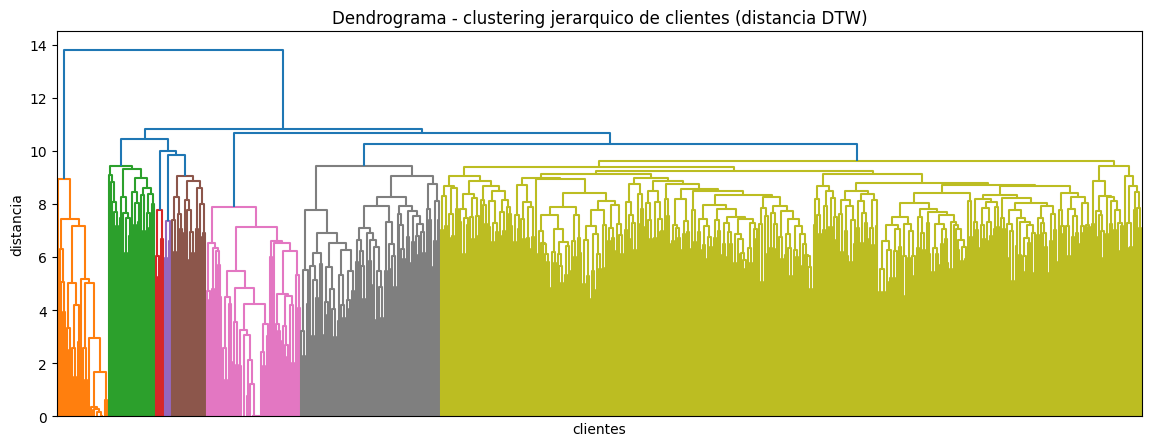

In [27]:
import matplotlib.pyplot as plt

# dendrograma, para elegir a ojo cuantos clusters tiene sentido cortar
plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True)
plt.title("Dendrograma - clustering jerarquico de clientes (distancia DTW)")
plt.xlabel("clientes")
plt.ylabel("distancia")
plt.show()


In [28]:
# defino la cantidad de clusters (ajusto despues de mirar el dendrograma)
#
# AJUSTE: antes tenía n_clusters=5, dejaba 463 de los ~597 clientes en un solo cluster (14.3M filas), que era el que reventaba la RAM en el loop de la seccion 5.4.
# Subo el corte inicial y, en la celda siguiente, agrego un rebalanceo automatico: si despues de este corte algun cluster sigue superando MAX_FILAS_POR_CLUSTER filas, se vuelve a partir en 2 usando su propia submatriz de distancias DTW.

PARAM['n_clusters'] = 20
MAX_FILAS_POR_CLUSTER = 1_500_000  # ajustar segun la RAM disponible en el runtime de Colab

cluster_labels = fcluster(Z, t=PARAM['n_clusters'], criterion="maxclust")

tb_clusters = pl.DataFrame({
    "customer_id": clientes,
    "cluster_id": cluster_labels,
}).with_columns(pl.col("cluster_id").cast(pl.Int32))

tb_clusters.head()


customer_id,cluster_id
i64,i32
10001,18
10002,2
10003,18
10004,18
10005,18


### 3.4b Rebalanceo automatico de clusters (por filas, no solo por cantidad de clientes)

Un corte jerarquico parejo en *cantidad de clientes* no garantiza clusters parejos en *cantidad de filas de `tb_sellin`* (unos clientes tienen mucha mas historia/actividad que otros, y ademas `sell-in-zeroes` completa ceros estructurales para todo par cliente-producto). Por eso el chequeo de tamaño real se hace en filas, no en clientes, y cualquier cluster que se pase del techo se vuelve a partir.

In [29]:
def rebalancear_clusters(tb_clusters, clientes, matriz_dtw_full, tb_sellin, max_filas):
    """
    Si algun cluster tiene mas de `max_filas` filas en tb_sellin, lo particiona en 2 usando
    su propia submatriz de distancias DTW (linkage + fcluster con t=2), y repite hasta que
    todos los clusters resultantes esten por debajo del techo (o no se puedan partir mas,
    ej. quedó 1 solo cliente). No recalcula la matriz DTW completa: reutiliza matriz_dtw_full.
    """
    cliente_a_idx = {c: i for i, c in enumerate(clientes)}
    asignacion = dict(zip(tb_clusters["customer_id"].to_list(), tb_clusters["cluster_id"].to_list()))
    siguiente_id = max(asignacion.values()) + 1

    def filas_de(customer_ids):
        return tb_sellin.filter(pl.col("customer_id").is_in(customer_ids)).height

    cambio = True
    while cambio:
        cambio = False
        for cid in sorted(set(asignacion.values())):
            miembros = [c for c, v in asignacion.items() if v == cid]
            if len(miembros) < 2:
                continue

            n_filas = filas_de(miembros)
            if n_filas <= max_filas:
                continue

            print(f"  cluster {cid}: {len(miembros)} clientes / {n_filas} filas -> se parte en 2")

            idxs = [cliente_a_idx[c] for c in miembros]
            sub_matriz = matriz_dtw_full[np.ix_(idxs, idxs)]
            sub_condensada = squareform(sub_matriz, checks=False)
            sub_Z = linkage(sub_condensada, method="average")
            sub_labels = fcluster(sub_Z, t=2, criterion="maxclust")

            # al subgrupo 2 le asigno un cluster_id nuevo; el subgrupo 1 se queda con el mismo
            for c, lbl in zip(miembros, sub_labels):
                if lbl == 2:
                    asignacion[c] = siguiente_id
            siguiente_id += 1
            cambio = True

    tb_clusters_bal = pl.DataFrame({
        "customer_id": list(asignacion.keys()),
        "cluster_id": list(asignacion.values()),
    }).with_columns(pl.col("cluster_id").cast(pl.Int32)).sort("customer_id")

    return tb_clusters_bal


tb_clusters = rebalancear_clusters(tb_clusters, clientes, matriz_dtw_full, tb_sellin, MAX_FILAS_POR_CLUSTER)

# reindexo cluster_id a 1..k consecutivos, solo por prolijidad (no afecta el resto del pipeline)
ids_unicos = sorted(tb_clusters["cluster_id"].unique().to_list())
mapa_ids = {viejo: nuevo for nuevo, viejo in enumerate(ids_unicos, start=1)}
tb_clusters = tb_clusters.with_columns(
    pl.col("cluster_id").replace(mapa_ids).cast(pl.Int32)
)

print("clusters finales:", tb_clusters["cluster_id"].n_unique())

# diagnostico de balance real (en FILAS, que es lo que importa para la RAM)
tb_sellin.join(tb_clusters, on="customer_id", how="left").group_by("cluster_id").agg(
    pl.len().alias("n_filas"),
    pl.col("customer_id").n_unique().alias("n_clientes")
).sort("cluster_id")


  cluster 15: 61 clientes / 1904620 filas -> se parte en 2
  cluster 16: 104 clientes / 3248302 filas -> se parte en 2
  cluster 18: 139 clientes / 4344016 filas -> se parte en 2
  cluster 21: 49 clientes / 1531999 filas -> se parte en 2
  cluster 22: 93 clientes / 2901560 filas -> se parte en 2
  cluster 23: 117 clientes / 3665630 filas -> se parte en 2
  cluster 21: 48 clientes / 1500477 filas -> se parte en 2
  cluster 23: 52 clientes / 1617485 filas -> se parte en 2
  cluster 25: 82 clientes / 2555603 filas -> se parte en 2
  cluster 26: 65 clientes / 2048145 filas -> se parte en 2
  cluster 23: 49 clientes / 1522919 filas -> se parte en 2
  cluster 29: 78 clientes / 2429515 filas -> se parte en 2
  cluster 32: 67 clientes / 2088270 filas -> se parte en 2
  cluster 33: 64 clientes / 1993704 filas -> se parte en 2
clusters finales: 34


cluster_id,n_filas,n_clientes
i32,u32,u32
1,753129,28
2,157610,5
3,31522,1
4,220654,7
5,409786,13
…,…,…
30,567396,18
31,878682,28
32,94566,3


### 3.5 Verificación de los clusters

In [30]:
# cantidad de clientes por cluster
tb_clusters.group_by("cluster_id").agg(pl.len().alias("n_clientes")).sort("cluster_id")


cluster_id,n_clientes
i32,u32
1,28
2,5
3,1
4,7
5,13
…,…
30,18
31,28
32,3


In [31]:
# guardo la asignacion de clusters (ya estamos parados en la carpeta del experimento, por el chdir de la seccion 0)
tb_clusters.write_csv("tb_clusters.csv")


# 4 Feature engineering local + entrenamiento por cluster

Esta sección corre dentro de un loop por cluster, para que en ningún momento tengamos el dataset completo (17M filas × cientos de columnas) en RAM simultáneamente.

Antes del loop, defino funciones reutilizables (historia, categorías/globales, escalado+clase) que después se aplican cluster por cluster.

### 4.1 Función: features de historia (lags, Δ lags, rolling, tendencia, max/min)

In [32]:
# lags a usar: tn_0 = mes actual, tn_1..tn_11 = meses anteriores
LAGS = list(range(0, 12))

def agregar_features_historia(df):
    df = df.sort(["customer_id", "product_id", "periodo"])

    grp = ["customer_id", "product_id"]

    # lags de tn
    df = df.with_columns([
        pl.col("tn").shift(lag).over(grp).alias(f"tn_{lag}")
        for lag in LAGS
    ])

    # delta entre lags consecutivos (captura tendencia de corto plazo)
    df = df.with_columns([
        (pl.col(f"tn_{lag}") - pl.col(f"tn_{lag+1}")).alias(f"delta_tn_{lag}_{lag+1}")
        for lag in LAGS[:-1]
    ])

    # medias moviles, desvio, min, max en distintas ventanas
    for w in [3, 6, 12]:
        df = df.with_columns([
            pl.col("tn").rolling_mean(window_size=w).over(grp).alias(f"tn_media_{w}"),
            pl.col("tn").rolling_std(window_size=w).over(grp).alias(f"tn_std_{w}"),
            pl.col("tn").rolling_max(window_size=w).over(grp).alias(f"tn_max_{w}"),
            pl.col("tn").rolling_min(window_size=w).over(grp).alias(f"tn_min_{w}"),
        ])

    # tendencia aproximada: pendiente entre el valor actual y el valor hace w-1 meses
    for w in [3, 6, 12]:
        df = df.with_columns(
            ((pl.col("tn_0") - pl.col(f"tn_{w-1}")) / (w - 1)).alias(f"tn_tend_{w}")
        )

    return df


### 4.2 Función: features de intermitencia (ceros)

El dataset `sell-in-zeroes` agrega intermitencia real (muchos ceros a nivel cliente-producto), asi que estas features ayudan al modelo a distinguir "venta baja" de "producto que dejó de venderse".

In [33]:
def agregar_features_intermitencia(df):
    grp = ["customer_id", "product_id"]

    # cantidad de meses con tn == 0 en los ultimos 3/6/12 meses
    df = df.with_columns(
        (pl.col("tn") == 0).cast(pl.Int32).alias("_es_cero")
    )

    for w in [3, 6, 12]:
        df = df.with_columns(
            pl.col("_es_cero").rolling_sum(window_size=w).over(grp).alias(f"ceros_ult_{w}")
        )

    df = df.drop("_es_cero")

    return df


### 4.2b Función: features de estacionalidad

No había ningún feature de mes/estación. Agrego el mes calendario, el trimestre, y una
codificación cíclica (`seno`/`coseno`) del mes para que el modelo pueda aprender un patrón
anual que se repite (dic distinto de jun, etc.) sin depender solo de los lags.

In [34]:
def agregar_features_estacionalidad(df):
    df = df.with_columns(
        (pl.col("periodo") % 100).alias("mes")
    )
    df = df.with_columns([
        ((pl.col("mes") - 1) // 3 + 1).alias("trimestre"),
        (pl.col("mes") * (2 * np.pi / 12)).sin().alias("mes_sin"),
        (pl.col("mes") * (2 * np.pi / 12)).cos().alias("mes_cos"),
    ])
    return df


### 4.3 Función: categorías de producto + agregaciones globales

In [35]:
def agregar_features_categoricas_y_globales(df):
    # categorias del producto
    df = df.join(
        tb_productos.select(["product_id", "cat1", "cat2", "cat3", "brand"]),
        on="product_id", how="left"
    )

    # producto base (para el join contra tn_total_producto_base)
    df = df.join(tb_producto_base, on="product_id", how="left")

    # agregaciones globales precalculadas en la seccion 2
    df = df.join(tb_agg_producto_periodo, on=["product_id", "periodo"], how="left")
    df = df.join(tb_agg_cliente_periodo, on=["customer_id", "periodo"], how="left")
    df = df.join(tb_agg_base_periodo, on=["producto_base_id", "periodo"], how="left")
    df = df.join(tb_agg_mercado_periodo, on="periodo", how="left")
    df = df.join(tb_stock_producto_periodo, on=["product_id", "periodo"], how="left")

    # participacion del cliente/producto dentro de esos totales (features derivadas)
    df = df.with_columns([
        (pl.col("tn") / pl.col("tn_total_producto")).alias("participacion_en_producto"),
        (pl.col("tn") / pl.col("tn_total_cliente")).alias("participacion_en_cliente"),
    ])

    return df


### 4.4 Función: escalado y creación de la clase

`tn_promedio` = media móvil de ventana 2 (mes actual + mes anterior). Se mantiene como **feature** (señal de escala/nivel reciente), pero el target ya no se construye dividiendo por él: el target es `tn_futuro` directo (el `tn` real dentro de `HORIZONTE` meses), para evitar la inestabilidad numérica de dividir por un promedio cercano a cero (ver diagnóstico en la sección 8, que fue el que motivó este cambio).

In [36]:
HORIZONTE = 2  # predecimos 2 meses hacia adelante (dic-2019 -> feb-2020)

# Luego de varias pruebas, llegué a esta version nueva: el target es tn_futuro DIRECTO (toneladas reales dentro de HORIZONTE meses).
# tn_promedio se sigue calculando, pero ahora es solo un FEATURE mas (una senial de escala
# para el modelo), no un denominador. Esto es ademas el uso correcto de Tweedie: tn es una
# variable no negativa con muchos ceros (intermitencia) y una cola continua positiva, que es
# exactamente la distribucion compuesta Poisson-Gamma que Tweedie modela.

def agregar_escalado_y_clase(df):
    grp = ["customer_id", "product_id"]

    # tn_promedio queda como FEATURE de escala/nivel reciente del cliente-producto
    df = df.with_columns(
        pl.col("tn").rolling_mean(window_size=2).over(grp).alias("tn_promedio")
    )

    # TARGET: tn real, HORIZONTE meses hacia adelante. Sin dividir por nada.
    df = df.with_columns(
        pl.col("tn").shift(-HORIZONTE).over(grp).alias("tn_futuro")
    )

    return df


### 4.4.1 Diagnóstico: tamaño real de cada cluster (filas, no solo clientes)
Antes de correr el loop pesado, chequeo cuántas filas de `tb_sellin` tiene cada cluster. Un cluster muy grande explica el `OOM` que viste en 4.6.

In [37]:
tb_sellin.join(tb_clusters, on="customer_id", how="left").group_by("cluster_id").agg(
    pl.len().alias("n_filas"),
    pl.col("customer_id").n_unique().alias("n_clientes")
).sort("cluster_id")


cluster_id,n_filas,n_clientes
i32,u32,u32
1,753129,28
2,157610,5
3,31522,1
4,220654,7
5,409786,13
…,…,…
30,567396,18
31,878682,28
32,94566,3


### 4.4.2 Nota: ya no hay filtro por `TN_PROMEDIO_MIN`

Con el cambio de diseño del target (sección 4.4: ahora predecimos `tn_futuro` directo, no un
ratio dividido por `tn_promedio`), el piso `TN_PROMEDIO_MIN` que excluía filas de bajo volumen
ya **no es necesario** — no hay ninguna división que se vuelva inestable. Todas las filas con
`tn_futuro` conocido entran al entrenamiento, incluidas las de venta intermitente/baja, que son
justamente las que Tweedie está diseñado para modelar bien (masa puntual en 0 + cola continua).
Esto también significa más cobertura real del LightGBM sobre los 780 productos a predecir,
en vez de depender del ensemble para el segmento de bajo volumen.

### 4.5 Columnas de features y target

In [38]:
COLS_ID = ["customer_id", "product_id", "periodo", "cluster_id"]
COLS_CATEGORICAS = ["cat1", "cat2", "cat3", "brand"]

# columnas auxiliares que NO deben entrar como feature (identificadores auxiliares y el target)
COLS_AUX = ["tn_futuro", "producto_base_id"]

# TARGET: tn futuro DIRECTO (ver seccion 4.4, ya no es un ratio escalado).
# Tweedie es apropiado para tn en su escala original: variable no negativa, con masa
# puntual en 0 (intermitencia) y cola continua positiva.
TARGET = "tn_futuro"

# parametros fijos de LightGBM pedidos por la catedra (no se tunean, van fijos en todos los modelos)
LGBM_PARAMS_FIJOS = {
    "objective": "tweedie",
    "max_bin": 1023,
}


### 4.6 Loop de entrenamiento y predicción por cluster

> **Nota:** este loop quedó como baseline inicial (sin validación temporal ni tuning, y sin el piso `TN_PROMEDIO_MIN`). Fue **reemplazado por la sección 5**, que además usa `objective=tweedie` y `max_bin=1023` como se indicó en clase que se hiciera. No hace falta correr esta celda — la dejo solo como referencia histórica del primer intento.

In [47]:

resultados_clusters = []
modelos_por_cluster = {}

periodo_max = tb_sellin["periodo"].max()  # 201912, el ultimo periodo con datos reales

n_clusters_reales = tb_clusters["cluster_id"].n_unique()
print("clusters a procesar:", n_clusters_reales)


clusters a procesar: 34


In [ ]:
'''
import gc

for cluster_id in sorted(tb_clusters["cluster_id"].unique().to_list()):

    print(f"=== cluster {cluster_id} ===")

    # clientes de este cluster
    clientes_cluster = tb_clusters.filter(pl.col("cluster_id") == cluster_id)["customer_id"]

    # subconjunto liviano: solo los clientes de este cluster
    sub = tb_sellin.filter(pl.col("customer_id").is_in(clientes_cluster))

    # bajo precision a float32 antes de generar features (a mitad de RAM que float64)
    sub = sub.with_columns(pl.col("tn").cast(pl.Float32))

    print("  filas del cluster:", sub.height)

    # pipeline de feature engineering, SOLO sobre este cluster
    sub = agregar_features_historia(sub)
    sub = agregar_features_intermitencia(sub)
    sub = agregar_features_categoricas_y_globales(sub)
    sub = agregar_escalado_y_clase(sub)
    sub = sub.with_columns(pl.lit(cluster_id).alias("cluster_id"))

    # fuerzo float32 en todas las columnas numericas nuevas (lags, rolling, etc.)
    cols_float = [c for c, t in zip(sub.columns, sub.dtypes) if t == pl.Float64]
    sub = sub.with_columns([pl.col(c).cast(pl.Float32) for c in cols_float])

    # columnas de features = todo lo que no es id, categorica original de texto, ni auxiliar
    cols_features_num = [
        c for c in sub.columns
        if c not in COLS_ID + COLS_CATEGORICAS + COLS_AUX + ["tn"]
    ]

    # ------- train -------
    train = sub.filter(
        pl.col(TARGET).is_not_null()
        & pl.col("tn_promedio").is_not_null()
        & (pl.col("tn_promedio") != 0)
    )

    if train.height == 0:
        print("  sin filas de entrenamiento, salteo cluster")
        del sub, train
        gc.collect()
        continue

    X_train = train.select(cols_features_num + COLS_CATEGORICAS).to_pandas()
    y_train = train[TARGET].to_pandas()

    for c in COLS_CATEGORICAS:
        X_train[c] = X_train[c].astype("category")

    modelo = lgb.LGBMRegressor(
        random_state=PARAM['semilla_primigenia'],
        n_estimators=500,
        verbosity=-1,
        **LGBM_PARAMS_FIJOS
    )
    modelo.fit(X_train, y_train, categorical_feature=COLS_CATEGORICAS)

    modelos_por_cluster[cluster_id] = modelo

    del X_train, y_train, train
    gc.collect()

    # ------- predict (periodo actual = 201912, target = 202002) -------
    a_predecir = sub.filter(
        (pl.col("periodo") == periodo_max)
        & pl.col("tn_promedio").is_not_null()
        & (pl.col("tn_promedio") != 0)
    )

    if a_predecir.height == 0:
        print("  sin filas para predecir, salteo cluster")
        del sub, a_predecir
        gc.collect()
        continue

    X_pred = a_predecir.select(cols_features_num + COLS_CATEGORICAS).to_pandas()
    for c in COLS_CATEGORICAS:
        X_pred[c] = X_pred[c].astype("category")

    pred_clase_escalada = modelo.predict(X_pred)
    tn_pred = pred_clase_escalada * a_predecir["tn_promedio"].to_numpy()

    resultado_cluster = a_predecir.select(["customer_id", "product_id"]).with_columns([
        pl.Series("tn_pred", tn_pred),
        pl.lit(cluster_id).alias("cluster_id")
    ])

    resultados_clusters.append(resultado_cluster)

    print("  filas predichas:", resultado_cluster.height)

    # libero TODO lo pesado de este cluster antes de pasar al siguiente
    del sub, a_predecir, X_pred, pred_clase_escalada, resultado_cluster
    gc.collect()
'''

### 4.7 Consolidación de resultados de todos los clusters

In [ ]:
'''
tb_pred_lightgbm_cliente_producto = pl.concat(resultados_clusters)

print(tb_pred_lightgbm_cliente_producto.shape)
tb_pred_lightgbm_cliente_producto.head()
'''

In [ ]:
'''
# guardo la prediccion a nivel cliente-producto (util para debug / auditoria)
tb_pred_lightgbm_cliente_producto.write_csv("pred_lightgbm_cliente_producto.csv")
'''

# 5 Validación temporal + tuning de hiperparámetros

Esta sección **reemplaza** el entrenamiento ingenuo de la sección 4 (que usaba hiperparámetros default y sin validación) por una versión con:

- **Validación temporal de un solo periodo**, imitando exactamente la estructura del submit final: se entrena con datos hasta `periodo_validacion - 2` y se valida contra el `tn` real de `periodo_validacion` (el último periodo con target conocido). Nada de random split — folds al azar romperían la estructura temporal y filtrarían información del futuro.
- **Búsqueda de hiperparámetros cluster por cluster**
- **Early stopping** usando la validación para elegir la cantidad de árboles.
- Una vez elegidos los mejores hiperparámetros y la mejor iteración, se **reentrena el modelo final con train+validación combinados** (para no desperdiciar el mes de validación en la predicción real), y recién ahí se predice `periodo_max` (feb-2020).

### 5.1 Aritmética de periodos y definición del periodo de validación

In [48]:
def sumar_meses(periodo, delta):
    """periodo en formato YYYYMM (int). Suma/resta 'delta' meses respetando cambio de anio."""
    anio = periodo // 100
    mes = periodo % 100
    total = anio * 12 + (mes - 1) + delta
    anio2 = total // 12
    mes2 = total % 12 + 1
    return anio2 * 100 + mes2


PERIODO_VALIDACION = sumar_meses(periodo_max, -HORIZONTE)

print("periodo_max (ultimo real):", periodo_max)
print("periodo_validacion (pseudo test, imita el submit):", PERIODO_VALIDACION)
print("periodo objetivo final a predecir:", sumar_meses(periodo_max, HORIZONTE))


periodo_max (ultimo real): 201912
periodo_validacion (pseudo test, imita el submit): 201910
periodo objetivo final a predecir: 202002


### 5.2 Métrica de negocio: Total Forecast Error (a nivel producto)
se suma `tn` real y `tn` predicho de todos los clientes para cada producto, y se compara el error absoluto total contra la venta total real.

In [49]:
def total_forecast_error(df_val, col_real, col_pred):
    agregado = (
        df_val
        .group_by("product_id")
        .agg([
            pl.col(col_real).sum().alias("real_total"),
            pl.col(col_pred).sum().alias("pred_total"),
        ])
    )
    error_abs = (agregado["real_total"] - agregado["pred_total"]).abs().sum()
    total_real = agregado["real_total"].sum()

    if total_real == 0:
        # caso borde: no hubo venta real de ningun producto en este periodo de validacion
        # (le pasa a clusters muy chicos/de bajo volumen). El ratio no esta definido:
        # si tambien predije ~0, el error es perfecto (0); si no, lo marco como "malo" (inf)
        # en vez de romper con ZeroDivisionError.
        return 0.0 if abs(error_abs) < 1e-6 else float("inf")

    return error_abs / total_real


### 5.3 Grilla de hiperparámetros y función de búsqueda

In [50]:
import itertools
import random
import gc

GRILLA_HIPERPARAMETROS = {
    "num_leaves": [15, 31, 63],
    "learning_rate": [0.03, 0.05, 0.1],
    "min_child_samples": [20, 50],
    "feature_fraction": [0.8, 1.0],
    "bagging_fraction": [0.8, 1.0],
}

N_COMBINACIONES = 8  # cuantas combinaciones probar por cluster (grilla completa es mucho mas grande)

def generar_combinaciones(grilla, n, seed):
    todas = list(itertools.product(*grilla.values()))
    random.Random(seed).shuffle(todas)
    claves = list(grilla.keys())
    return [dict(zip(claves, combo)) for combo in todas[:n]]


def buscar_mejores_hiperparametros(X_train, y_train, X_val, y_val, categoricas, seed,
                                    val_product_id, n_combinaciones=None):
    """
    Devuelve los mejores hiperparametros, la mejor iteracion, el rmse (referencia) y el
    total forecast error (TFE) de validacion, y el modelo ya entrenado que gano la busqueda.

    Con el target nuevo (tn_futuro directo, ver seccion 4.4) la prediccion del modelo YA
    esta en toneladas -> no hace falta reconstruir multiplicando por tn_promedio como antes.
    y_val ES el tn real, asi que se usa directo tanto para el rmse como para el TFE.

    El criterio de seleccion sigue siendo el TFE (metrica de negocio, la misma que evalua
    Kaggle a nivel producto), con desempate por RMSE. El primer candidato SIEMPRE se acepta
    como punto de partida, para que 'mejor_modelo' nunca quede None (caso borde: tn real
    0 para todos los productos del cluster en el periodo de validacion -> TFE = inf para
    cualquier prediccion no nula).

    n_combinaciones: permite pisar N_COMBINACIONES por llamada. Util para clusters grandes,
    donde entrenar 8 modelos LGBM seguidos sobre millones de filas es lo que dispara el pico
    de RAM -- ver AJUSTE en la seccion 5.4.
    """
    combinaciones = generar_combinaciones(
        GRILLA_HIPERPARAMETROS, n_combinaciones or N_COMBINACIONES, seed
    )

    mejor_criterio = None   # tupla (tfe, rmse), menor es mejor
    mejor_tfe = None
    mejor_rmse_reportado = None
    mejores_params = None
    mejor_n_estimators = None
    mejor_modelo = None

    for params in combinaciones:
        modelo = lgb.LGBMRegressor(
            random_state=seed,
            n_estimators=2000,   # techo alto, el early stopping corta antes
            verbosity=-1,
            **LGBM_PARAMS_FIJOS,
            **params
        )
        modelo.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="rmse",
            categorical_feature=categoricas,
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        rmse_val = modelo.best_score_["valid_0"]["rmse"]

        # prediccion ya esta en tn (target = tn_futuro directo, sin reescalado)
        tn_pred = modelo.predict(X_val)

        df_tfe = pl.DataFrame({
            "product_id": val_product_id,
            "tn_real": y_val.to_numpy(),
            "tn_pred": tn_pred,
        })
        tfe_val = total_forecast_error(df_tfe, "tn_real", "tn_pred")
        if not np.isfinite(tfe_val):
            tfe_val = np.inf

        criterio_actual = (tfe_val, rmse_val)

        if mejor_criterio is None or criterio_actual < mejor_criterio:
            mejor_criterio = criterio_actual
            mejor_tfe = tfe_val
            mejor_rmse_reportado = rmse_val
            mejores_params = params
            mejor_n_estimators = modelo.best_iteration_
            mejor_modelo = modelo
        else:
            del modelo
            gc.collect()

    if not np.isfinite(mejor_tfe):
        print("  [aviso] TFE de validacion es inf para todos los candidatos en este cluster "
              "(probablemente tn real = 0 para todos los productos en el periodo de validacion). "
              "Se selecciono el modelo con mejor RMSE como fallback.")

    return mejores_params, mejor_n_estimators, mejor_rmse_reportado, mejor_tfe, mejor_modelo


### 5.4 Loop principal: split temporal + tuning + entrenamiento final por cluster

In [ ]:
import gc

resultados_clusters = []       # predicciones finales (periodo_max -> feb 2020)
modelos_por_cluster = {}
metricas_por_cluster = []      # para la tabla resumen de 5.5

for cluster_id in sorted(tb_clusters["cluster_id"].unique().to_list()):

    print(f"=== cluster {cluster_id} ===")

    clientes_cluster = tb_clusters.filter(pl.col("cluster_id") == cluster_id)["customer_id"]
    sub = tb_sellin.filter(pl.col("customer_id").is_in(clientes_cluster))
    sub = sub.with_columns(pl.col("tn").cast(pl.Float32))

    print("  filas del cluster (antes de filtrar pares inactivos):", sub.height)

    # saco los pares cliente-producto que NUNCA vendieron nada en todo el historico:
    # el dataset sell-in-zeros completa con cero TODA combinacion posible, asi que sin este
    # filtro entran millones de filas que son ceros estructurales (el cliente nunca compro
    # ese producto) y no aportan señal.
    # Esto es distinto de filtrar por tn_promedio: NO recorta la venta intermitente real
    # (un par con 1 sola venta en 24 meses se mantiene), solo saca los pares 100% muertos.
    pares_activos = (
        sub.group_by(["customer_id", "product_id"])
        .agg(pl.col("tn").sum().alias("tn_total_par"))
        .filter(pl.col("tn_total_par") > 0)
        .select(["customer_id", "product_id"])
    )
    sub = sub.join(pares_activos, on=["customer_id", "product_id"], how="inner")
    del pares_activos
    gc.collect()

    print("  filas del cluster (pares activos):", sub.height)

    # pipeline de feature engineering (mismas funciones de la seccion 4, + estacionalidad)
    sub = agregar_features_historia(sub)
    sub = agregar_features_intermitencia(sub)
    sub = agregar_features_estacionalidad(sub)
    sub = agregar_features_categoricas_y_globales(sub)
    sub = agregar_escalado_y_clase(sub)
    sub = sub.with_columns(pl.lit(cluster_id).alias("cluster_id"))

    cols_float = [c for c, t in zip(sub.columns, sub.dtypes) if t == pl.Float64]
    sub = sub.with_columns([pl.col(c).cast(pl.Float32) for c in cols_float])

    # --- AJUSTE: monitoreo de RAM real del cluster tras el feature engineering ---
    print(f"  tamano en RAM tras feature engineering: {sub.estimated_size('mb'):.0f} MB")

    cols_features_num = [
        c for c in sub.columns
        if c not in COLS_ID + COLS_CATEGORICAS + COLS_AUX + ["tn"]
    ]

    # ya no hay piso TN_PROMEDIO_MIN: con el target directo (tn_futuro), todas las filas
    # con target conocido entran al entrenamiento, incluida la venta intermitente/baja
    filas_validas = pl.col(TARGET).is_not_null()

    # split temporal: train = todo lo anterior al periodo de validacion; val = ese unico periodo
    train = sub.filter(filas_validas & (pl.col("periodo") < PERIODO_VALIDACION))
    val = sub.filter(filas_validas & (pl.col("periodo") == PERIODO_VALIDACION))

    if train.height == 0 or val.height == 0:
        print("  sin datos suficientes para train/val, salteo cluster")
        del sub, train, val
        gc.collect()
        continue

    X_train = train.select(cols_features_num + COLS_CATEGORICAS).to_pandas()
    y_train = train[TARGET].to_pandas()
    X_val = val.select(cols_features_num + COLS_CATEGORICAS).to_pandas()
    y_val = val[TARGET].to_pandas()

    for c in COLS_CATEGORICAS:
        X_train[c] = X_train[c].astype("category")
        X_val[c] = X_val[c].astype("category")

    # ------- busqueda de hiperparametros, seleccionando por TFE (metrica de negocio) -------

    n_combos_cluster = 8 if train.height < 2_000_000 else 4
    mejores_params, mejor_n_estimators, mejor_rmse, mejor_tfe_busqueda, mejor_modelo = buscar_mejores_hiperparametros(
        X_train, y_train, X_val, y_val, COLS_CATEGORICAS, seed=PARAM['semilla_primigenia'],
        val_product_id=val["product_id"].to_numpy(),
        n_combinaciones=n_combos_cluster,
    )
    print("  mejores hiperparametros:", mejores_params, "| n_estimators:", mejor_n_estimators,
          "| rmse val (ref):", round(mejor_rmse, 5),
          "| tfe val (criterio de seleccion):", round(mejor_tfe_busqueda, 4))

    tfe = mejor_tfe_busqueda

    metricas_por_cluster.append({
        "cluster_id": cluster_id,
        "n_filas_train": train.height,
        "n_filas_val": val.height,
        "rmse_val_tn": mejor_rmse,
        "total_forecast_error_val": tfe,
        "mejores_params": mejores_params,
        "n_estimators": mejor_n_estimators,
    })

    del mejor_modelo, X_val, y_val, val
    del X_train, y_train, train
    gc.collect()

    # ------- reentreno final: train + validacion combinados, mismos hiperparametros -------
    train_final = sub.filter(filas_validas & (pl.col("periodo") <= PERIODO_VALIDACION))
    X_train_final = train_final.select(cols_features_num + COLS_CATEGORICAS).to_pandas()
    y_train_final = train_final[TARGET].to_pandas()
    for c in COLS_CATEGORICAS:
        X_train_final[c] = X_train_final[c].astype("category")

    modelo_final = lgb.LGBMRegressor(
        random_state=PARAM['semilla_primigenia'],
        n_estimators=mejor_n_estimators, verbosity=-1,
        **LGBM_PARAMS_FIJOS, **mejores_params
    )
    modelo_final.fit(X_train_final, y_train_final, categorical_feature=COLS_CATEGORICAS)

    modelos_por_cluster[cluster_id] = modelo_final

    del train_final, X_train_final, y_train_final
    gc.collect()

    # ------- prediccion final (periodo_max -> periodo_max + HORIZONTE) -------
    a_predecir = sub.filter(pl.col("periodo") == periodo_max)

    if a_predecir.height == 0:
        print("  sin filas para predecir, salteo cluster")
        del sub, a_predecir
        gc.collect()
        continue

    X_pred = a_predecir.select(cols_features_num + COLS_CATEGORICAS).to_pandas()
    for c in COLS_CATEGORICAS:
        X_pred[c] = X_pred[c].astype("category")

    # prediccion ya esta en tn directamente: sin reescalado
    tn_pred = modelo_final.predict(X_pred)

    resultado_cluster = a_predecir.select(["customer_id", "product_id"]).with_columns([
        pl.Series("tn_pred", tn_pred),
        pl.lit(cluster_id).alias("cluster_id")
    ])
    resultados_clusters.append(resultado_cluster)

    print("  filas predichas:", resultado_cluster.height)

    del sub, a_predecir, X_pred, tn_pred, resultado_cluster
    gc.collect()


=== cluster 1 ===
  filas del cluster (antes de filtrar pares inactivos): 753129
  filas del cluster (pares activos): 144673
  tamano en RAM tras feature engineering: 46 MB
  mejores hiperparametros: {'num_leaves': 63, 'learning_rate': 0.05, 'min_child_samples': 50, 'feature_fraction': 1.0, 'bagging_fraction': 0.8} | n_estimators: 22 | rmse val (ref): 0.00501 | tfe val (criterio de seleccion): 1.8423
  filas predichas: 4412
=== cluster 2 ===
  filas del cluster (antes de filtrar pares inactivos): 157610
  filas del cluster (pares activos): 120418
  tamano en RAM tras feature engineering: 38 MB
  mejores hiperparametros: {'num_leaves': 15, 'learning_rate': 0.1, 'min_child_samples': 20, 'feature_fraction': 0.8, 'bagging_fraction': 1.0} | n_estimators: 45 | rmse val (ref): 3.23983 | tfe val (criterio de seleccion): 0.5961
  filas predichas: 3291
=== cluster 3 ===
  filas del cluster (antes de filtrar pares inactivos): 31522
  filas del cluster (pares activos): 16739
  tamano en RAM tras f

### 5.5 Tabla resumen de métricas de validación por cluster

In [ ]:
# mejores_params es un dict anidado (num_leaves, learning_rate, etc.) -> lo desanido
# en columnas propias, porque CSV no admite columnas anidadas
tb_metricas = pl.DataFrame(metricas_por_cluster).unnest("mejores_params")
tb_metricas.write_csv("metricas_validacion_por_cluster.csv")
tb_metricas


### 5.6 Consolidación de predicciones finales (feb-2020) por cliente-producto
Esta tabla **reemplaza** a la de la sección 4 (esta ya usa hiperparámetros tuneados por cluster).

In [ ]:
tb_pred_lightgbm_cliente_producto = pl.concat(resultados_clusters)

print(tb_pred_lightgbm_cliente_producto.shape)
tb_pred_lightgbm_cliente_producto.write_csv("pred_lightgbm_cliente_producto.csv")
tb_pred_lightgbm_cliente_producto.head()


# 6 Ensemble (LightGBM + AutoGluon + Regresión Lineal)

Promedio simple entre las 3 predicciones, a nivel `product_id`

El LightGBM predice a nivel `<cliente,producto>`, así que primero lo agrego sumando todos los clientes por producto.

### 6.1 Agregar LightGBM a nivel producto

In [ ]:
tb_pred_lightgbm_producto = (
    tb_pred_lightgbm_cliente_producto
    .group_by("product_id")
    .agg(pl.col("tn_pred").sum().alias("tn"))
    .rename({"tn": "tn_lightgbm"})
    .sort("product_id")
)

print(tb_pred_lightgbm_producto.shape)
tb_pred_lightgbm_producto.head()


### 6.2 Cargar predicciones de AutoGluon (z316) y Regresión Lineal (z403)

In [ ]:
import glob

# AutoGluon: el nombre de archivo depende de la metrica usada (global_eval_metric),
# asi que busco por patron en vez de nombre fijo
ruta_autogluon = glob.glob("/content/buckets/b1/exp/AutoGluon-01/AutoGluon_*.csv")

if len(ruta_autogluon) == 0:
    raise FileNotFoundError(
        "No se encontro la prediccion de AutoGluon. "
        "Correr primero z316_AutoGluon.ipynb (que guarda el CSV en su carpeta exp/)."
    )

print("uso:", ruta_autogluon[0])

tb_pred_autogluon_producto = (
    pl.read_csv(ruta_autogluon[0])
    .rename({"tn": "tn_autogluon"})
    .sort("product_id")
)

tb_pred_autogluon_producto.head()


In [ ]:
ruta_reglin = "/content/buckets/b1/exp/LR01/linreg.csv"

if not os.path.isfile(ruta_reglin):
    raise FileNotFoundError(
        "No se encontro la prediccion de Regresion Lineal. "
        "Correr primero z403_RegresionLineal.ipynb."
    )

tb_pred_reglin_producto = (
    pl.read_csv(ruta_reglin)
    .rename({"tn": "tn_reglin"})
    .sort("product_id")
)

tb_pred_reglin_producto.head()


### 6.3 Unión de las 3 predicciones

In [ ]:
tb_ensemble = (
    tb_apredecir  # los 780 product_id oficiales, para no perder ninguno
    .join(tb_pred_lightgbm_producto, on="product_id", how="left")
    .join(tb_pred_autogluon_producto, on="product_id", how="left")
    .join(tb_pred_reglin_producto, on="product_id", how="left")
)

# chequeo cuantos productos quedaron sin prediccion en cada metodo
print("sin lightgbm:", tb_ensemble["tn_lightgbm"].null_count())
print("sin autogluon:", tb_ensemble["tn_autogluon"].null_count())
print("sin reglin:", tb_ensemble["tn_reglin"].null_count())

tb_ensemble.head()


### 6.4 Promedio simple

Si a algún producto le falta la predicción de un método (por ejemplo el LightGBM no tuvo ese cliente-producto en ningún cluster), promedio solo entre los métodos que sí tienen valor para ese producto — no descarto el producto por eso.

In [ ]:
tb_ensemble = tb_ensemble.with_columns(
    pl.mean_horizontal(["tn_lightgbm", "tn_autogluon", "tn_reglin"]).alias("tn")
)

# si algun producto quedo sin NINGUNA de las 3 predicciones, lo marco para revisar a mano
sin_prediccion = tb_ensemble.filter(pl.col("tn").is_null())
print("productos sin ninguna prediccion:", sin_prediccion.height)
sin_prediccion


In [ ]:
# si algun producto quedo sin NINGUNA de las 3 predicciones (visto en la celda anterior),
# lo relleno con 0 en vez de dejarlo null: el CSV final tiene que tener SIEMPRE un valor
# numerico para los 780 product_id, no puede ir vacio
tb_ensemble = tb_ensemble.with_columns(
    pl.col("tn").fill_null(0.0).clip(lower_bound=0).alias("tn")
)

tb_final_ensemble = tb_ensemble.select(["product_id", "tn"]).sort("product_id")

print(tb_final_ensemble.shape)
tb_final_ensemble.head()


# 7 Submit a Kaggle

### 6.5 Validación dura del formato antes de escribir el CSV

In [ ]:
# ---- validacion dura del formato de entrega antes de escribir/subir el CSV ----
assert tb_final_ensemble.columns == ["product_id", "tn"], (
    f"columnas incorrectas: {tb_final_ensemble.columns}, se esperaba ['product_id', 'tn']"
)
assert tb_final_ensemble.height == 780, (
    f"cantidad de registros incorrecta: {tb_final_ensemble.height}, se esperaban 780"
)
assert tb_final_ensemble["product_id"].n_unique() == 780, "hay product_id duplicados"
assert tb_final_ensemble["tn"].null_count() == 0, "hay valores tn nulos, Kaggle va a rechazar el archivo"
assert set(tb_final_ensemble["product_id"].to_list()) == set(tb_apredecir["product_id"].to_list()), (
    "el set de product_id no coincide exactamente con los 780 a predecir"
)
print("OK: 780 registros, sin nulos, sin duplicados, product_id coincide con tb_apredecir")


In [ ]:
archivo = "ensemble_lightgbm_autogluon_reglin_final.csv"
mensaje = "Ensemble LightGBM(tweedie,maxbin1023) + AutoGluon + RegLin"

tb_final_ensemble.write_csv(archivo)

kaggle_submit(PARAM['kaggle_competition'], archivo, mensaje)
